In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
sns.set_theme(style="whitegrid")

# Load dataset and format dates
df = pd.read_csv("Sample - Superstore.csv", encoding="windows-1252")
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")

task 1

Sales Skewness: 12.97
Mean Sales: $229.86
Median Sales: $54.49


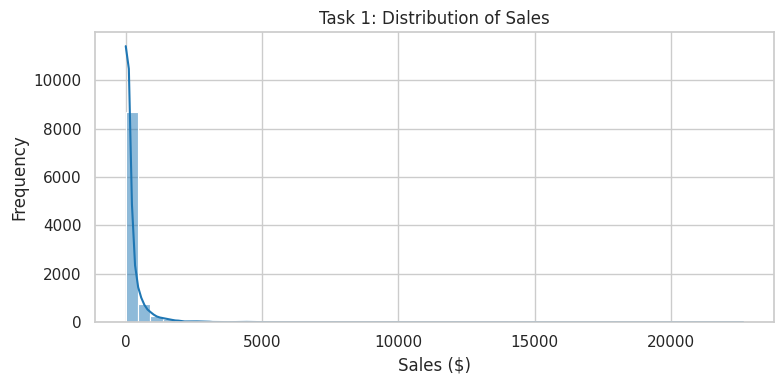

In [2]:
# Print distribution statistics
print(f"Sales Skewness: {df['Sales'].skew():.2f}")
print(f"Mean Sales: ${df['Sales'].mean():.2f}")
print(f"Median Sales: ${df['Sales'].median():.2f}")

# Plot histogram with KDE
plt.figure(figsize=(8, 4))
sns.histplot(df["Sales"], kde=True, bins=50, color="#1f77b4")
plt.title("Task 1: Distribution of Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

task 2

/tmp/ipykernel_1129/1890280303.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Category", y="Profit", ax=axes[0], palette="muted", inner="quartile")
/tmp/ipykernel_1129/1890280303.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="Category", y="Profit", jitter=True, alpha=0.3, ax=axes[1], palette="muted")


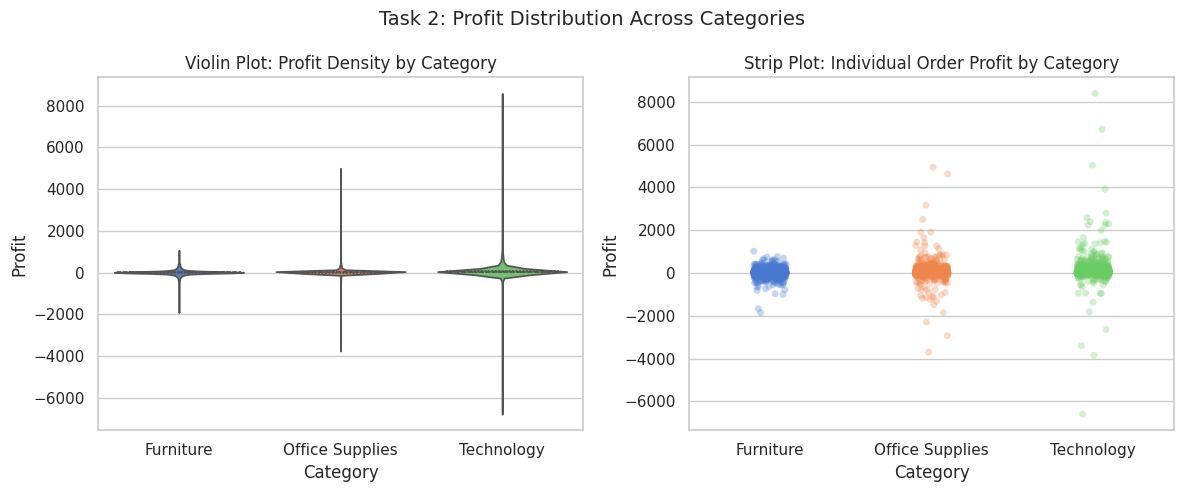

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Violin plot
sns.violinplot(data=df, x="Category", y="Profit", ax=axes[0], palette="muted", inner="quartile")
axes[0].set_title("Violin Plot: Profit Density by Category")

# Strip plot
sns.stripplot(data=df, x="Category", y="Profit", jitter=True, alpha=0.3, ax=axes[1], palette="muted")
axes[1].set_title("Strip Plot: Individual Order Profit by Category")

plt.suptitle("Task 2: Profit Distribution Across Categories", fontsize=14)
plt.tight_layout()
plt.show()

task3


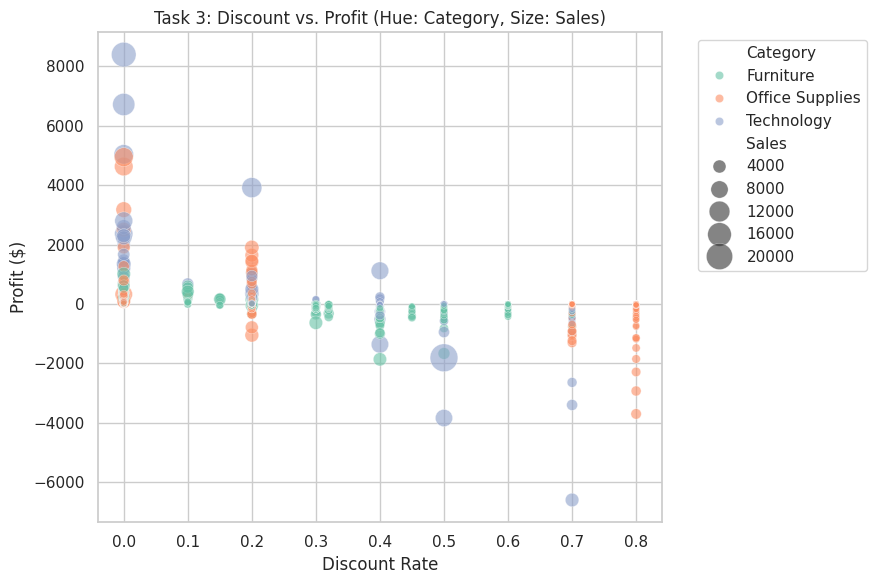

In [4]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    size="Sales",
    sizes=(20, 400),
    alpha=0.6,
    palette="Set2"
)
plt.title("Task 3: Discount vs. Profit (Hue: Category, Size: Sales)")
plt.xlabel("Discount Rate")
plt.ylabel("Profit ($)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

task 4

Pearson Correlation Matrix:
           Sales  Quantity  Discount  Profit
Sales     1.000     0.201    -0.028   0.479
Quantity  0.201     1.000     0.009   0.066
Discount -0.028     0.009     1.000  -0.219
Profit    0.479     0.066    -0.219   1.000

Spearman Correlation Matrix:
           Sales  Quantity  Discount  Profit
Sales     1.000     0.327    -0.057   0.518
Quantity  0.327     1.000    -0.001   0.234
Discount -0.057    -0.001     1.000  -0.543
Profit    0.518     0.234    -0.543   1.000


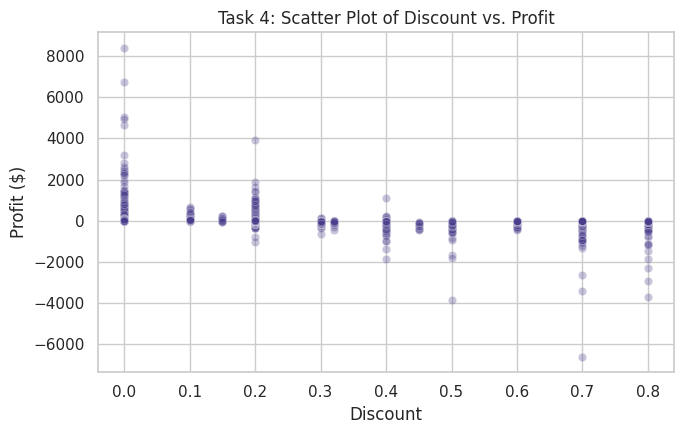

In [5]:
num_cols = ["Sales", "Quantity", "Discount", "Profit"]

pearson_corr = df[num_cols].corr(method="pearson")
spearman_corr = df[num_cols].corr(method="spearman")

print("Pearson Correlation Matrix:\n", pearson_corr.round(3))
print("\nSpearman Correlation Matrix:\n", spearman_corr.round(3))

# Scatter plot showing non-linear relationship between Discount and Profit
plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.3, color="darkslateblue")
plt.title("Task 4: Scatter Plot of Discount vs. Profit")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

task 5

Sales Pivot Table:
 Category  Furniture  Office Supplies  Technology         All
Region                                                      
Central   163797.16        167026.42   170416.31   501239.89
East      208291.20        205516.06   264973.98   678781.24
South     117298.68        125651.31   148771.91   391721.90
West      252612.74        220853.25   251991.83   725457.82
All       741999.80        719047.03   836154.03  2297200.86


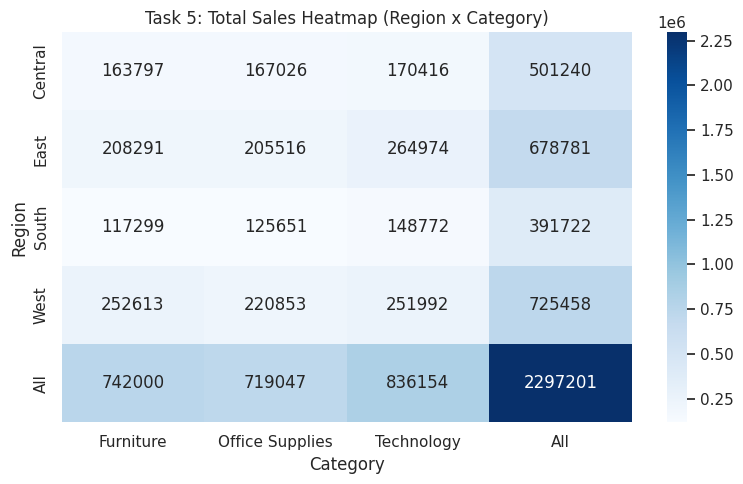

In [6]:
# Pivot table
pivot_sales = pd.pivot_table(
    df,
    index="Region",
    columns="Category",
    values="Sales",
    aggfunc="sum",
    margins=True
)

print("Sales Pivot Table:\n", pivot_sales.round(2))

# Heatmap visualization
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_sales, annot=True, fmt=".0f", cmap="Blues", cbar=True)
plt.title("Task 5: Total Sales Heatmap (Region x Category)")
plt.tight_layout()
plt.show()

task6

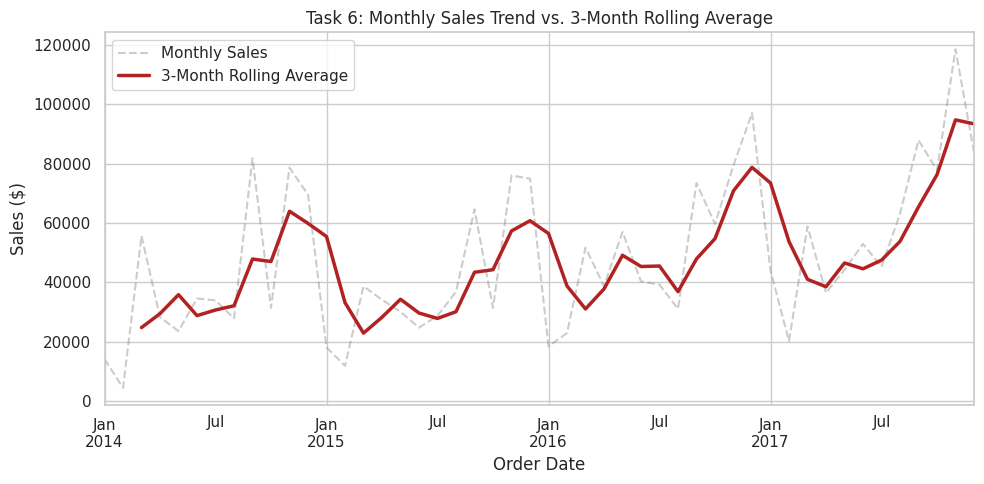

In [7]:
# Set index and resample
df_ts = df.set_index("Order Date")
monthly_sales = df_ts["Sales"].resample("ME").sum()
rolling_sales = monthly_sales.rolling(window=3).mean()

# Plot trend vs. noise
plt.figure(figsize=(10, 5))
monthly_sales.plot(label="Monthly Sales", alpha=0.4, color="gray", linestyle="--")
rolling_sales.plot(label="3-Month Rolling Average", color="firebrick", linewidth=2.5)
plt.title("Task 6: Monthly Sales Trend vs. 3-Month Rolling Average")
plt.xlabel("Order Date")
plt.ylabel("Sales ($)")
plt.legend()
plt.tight_layout()
plt.show()

task 7

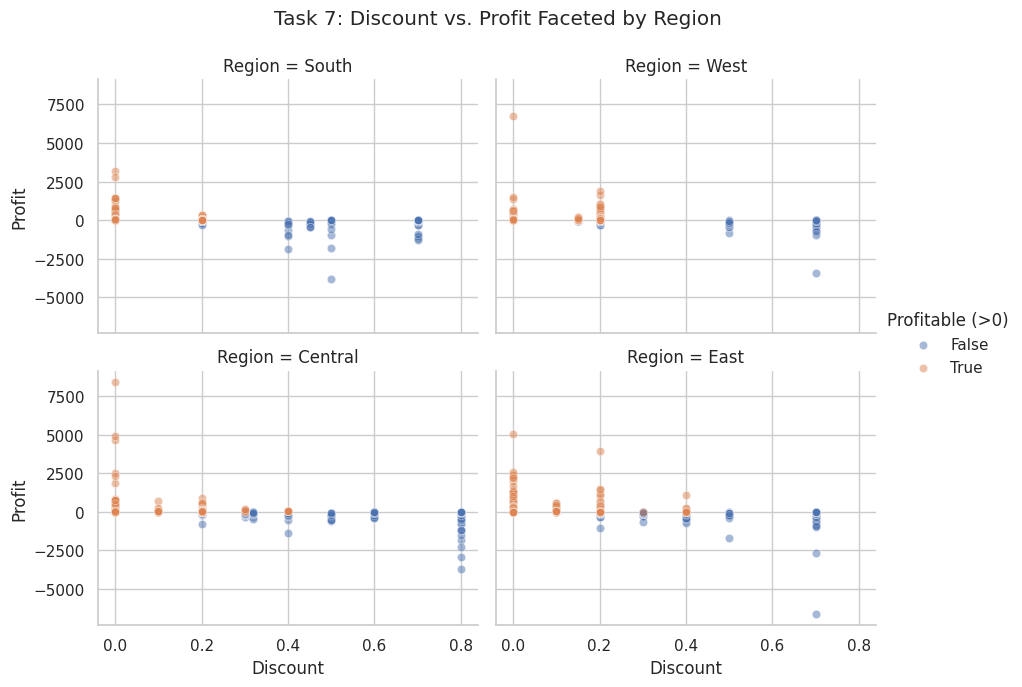

In [8]:
# Flag profitable orders
df["Profitable"] = df["Profit"] > 0

# Grid of scatter plots faceted by Region
g = sns.FacetGrid(df, col="Region", hue="Profitable", col_wrap=2, height=3.5, aspect=1.3)
g.map(sns.scatterplot, "Discount", "Profit", alpha=0.5)
g.add_legend(title="Profitable (>0)")
plt.subplots_adjust(top=0.88)
g.fig.suptitle("Task 7: Discount vs. Profit Faceted by Region")
plt.show()

task 8

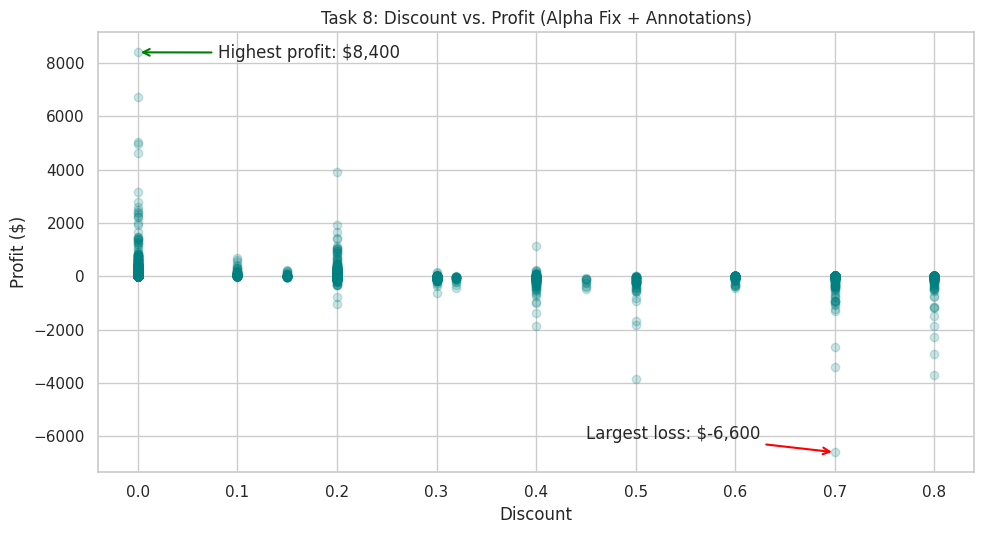

In [9]:
plt.figure(figsize=(10, 5.5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.2, color="teal")
plt.title("Task 8: Discount vs. Profit (Alpha Fix + Annotations)")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")

# Find outlier rows
best_order = df.loc[df["Profit"].idxmax()]
worst_order = df.loc[df["Profit"].idxmin()]

# Highest profit annotation
plt.annotate(
    f"Highest profit: ${best_order['Profit']:,.0f}",
    xy=(best_order["Discount"], best_order["Profit"]),
    xytext=(best_order["Discount"] + 0.08, best_order["Profit"] - 200),
    arrowprops=dict(arrowstyle="->", color="green", lw=1.5)
)

# Largest loss annotation
plt.annotate(
    f"Largest loss: ${worst_order['Profit']:,.0f}",
    xy=(worst_order["Discount"], worst_order["Profit"]),
    xytext=(worst_order["Discount"] - 0.25, worst_order["Profit"] + 500),
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5)
)

plt.tight_layout()
plt.show()